## RANDOM FOREST

Datasettet används främst för klassificeringsuppgifter, där målet är att förutsäga om en patient har hjärtsjukdom eller inte

In [3]:
import pandas as pd

df = pd.read_csv("../../data/Heart.csv", index_col=0)
df.head()

,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No


In [5]:
df_no_nulls = df.dropna()

df_no_nulls.info()

<class 'pandas.core.frame.DataFrame'>
Index: 297 entries, 1 to 302
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        297 non-null    int64  
 1   Sex        297 non-null    int64  
 2   ChestPain  297 non-null    object 
 3   RestBP     297 non-null    int64  
 4   Chol       297 non-null    int64  
 5   Fbs        297 non-null    int64  
 6   RestECG    297 non-null    int64  
 7   MaxHR      297 non-null    int64  
 8   ExAng      297 non-null    int64  
 9   Oldpeak    297 non-null    float64
 10  Slope      297 non-null    int64  
 11  Ca         297 non-null    float64
 12  Thal       297 non-null    object 
 13  AHD        297 non-null    object 
dtypes: float64(2), int64(9), object(3)
memory usage: 34.8+ KB


In [7]:

df_no_nulls["AHD"].value_counts()

AHD
No     160
Yes    137
Name: count, dtype: int64

In [10]:
df_no_nulls["ChestPain"].value_counts()

ChestPain
asymptomatic    142
nonanginal       83
nontypical       49
typical          23
Name: count, dtype: int64

In [13]:
# Gör om strängvärden till bools
df_dummies = pd.get_dummies(df_no_nulls, drop_first=True)
df_dummies.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable,AHD_Yes
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False,True
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False,False


In [ ]:
# Dela upp features och target/label
X, y = df_dummies.drop("AHD_Yes", axis=1), df_dummies["AHD_Yes"]
X.head()

,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,63,1,145,233,1,2,150,0,2.3,3,0.0,False,False,True,False,False
2,67,1,160,286,0,2,108,1,1.5,2,3.0,False,False,False,True,False
3,67,1,120,229,0,2,129,1,2.6,2,2.0,False,False,False,False,True
4,37,1,130,250,0,0,187,0,3.5,3,0.0,True,False,False,True,False
5,41,0,130,204,0,2,172,0,1.4,1,0.0,False,True,False,True,False


In [16]:
y.head()

1    False
2     True
3     True
4    False
5    False
Name: AHD_Yes, dtype: bool

### TRAIN TEST SPLIT DATA

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.33, random_state=42)

X_train.shape, X_test.shape

((198, 16), (99, 16))

In [25]:
# INTE SKALNING FÖR RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred[:10]

array([False, False, False,  True, False, False,  True,  True,  True,
       False])

In [23]:
y_test[:10].values

array([False,  True, False,  True, False, False, False, False,  True,
       False])

## predictar 2 fel

## EVALUATION

              precision    recall  f1-score   support

       False       0.81      0.89      0.85        53
        True       0.85      0.76      0.80        46

    accuracy                           0.83        99
   macro avg       0.83      0.82      0.83        99
weighted avg       0.83      0.83      0.83        99



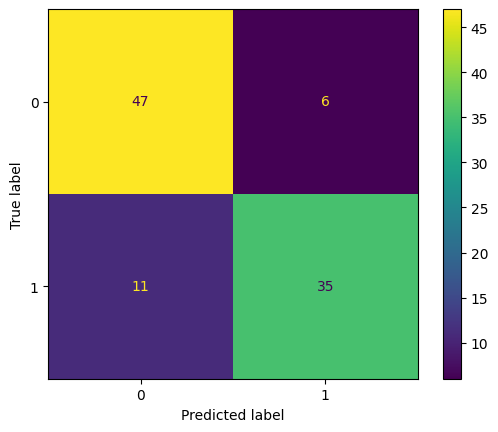

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay,classification_report

print(classification_report(y_test,y_pred))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot()

## Feature importance

In [ ]:
# Använd rrandom forest ffeature importance
model.feature_importances_

array([0.10286501, 0.02511153, 0.0707346 , 0.09343864, 0.00647174,
       0.0219155 , 0.12440249, 0.02848858, 0.09796534, 0.02244757,
       0.16171638, 0.04619105, 0.01048095, 0.01778791, 0.10393358,
       0.06604911])

In [28]:
df.columns

Index(['Age', 'Sex', 'ChestPain', 'RestBP', 'Chol', 'Fbs', 'RestECG', 'MaxHR',
       'ExAng', 'Oldpeak', 'Slope', 'Ca', 'Thal', 'AHD'],
      dtype='object')

In [31]:
len(X.columns), len(model.feature_importances_)

(16, 16)

In [36]:
feature_importance = pd.DataFrame([X.columns, model.feature_importances_])
feature_importance

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,Age,Sex,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,ChestPain_nonanginal,ChestPain_nontypical,ChestPain_typical,Thal_normal,Thal_reversable
1,0.102865,0.025112,0.070735,0.093439,0.006472,0.021915,0.124402,0.028489,0.097965,0.022448,0.161716,0.046191,0.010481,0.017788,0.103934,0.066049


In [41]:
#Transponera, rader bli kolumner o vise versa
feature_importance = feature_importance.T
feature_importance.columns = ["Feature", "Importance"]

In [42]:
feature_importance

,Feature,Importance
0,Age,0.102865
1,Sex,0.025112
2,RestBP,0.070735
3,Chol,0.093439
4,Fbs,0.006472
5,RestECG,0.021915
6,MaxHR,0.124402
7,ExAng,0.028489
8,Oldpeak,0.097965
9,Slope,0.022448


In [43]:
feature_importance = feature_importance.sort_values(by = "Importance", ascending=False)
feature_importance

,Feature,Importance
10,Ca,0.161716
6,MaxHR,0.124402
14,Thal_normal,0.103934
0,Age,0.102865
8,Oldpeak,0.097965
3,Chol,0.093439
2,RestBP,0.070735
15,Thal_reversable,0.066049
11,ChestPain_nonanginal,0.046191
7,ExAng,0.028489


In [44]:
feature_importance["Importance"].sum()

np.float64(0.9999999999999998)

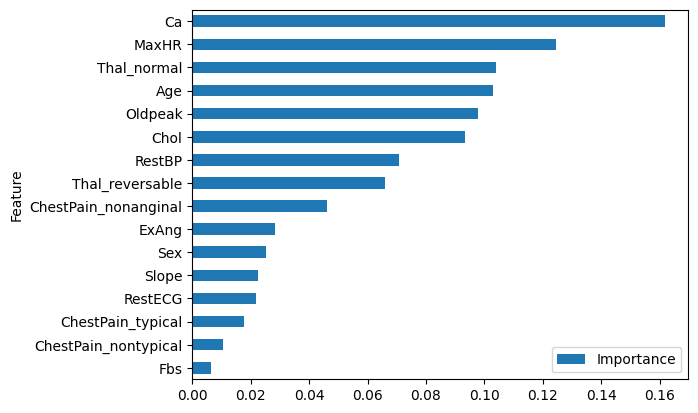

In [45]:
ax = feature_importance.plot(y="Importance", x="Feature", kind="barh")
ax.invert_yaxis()